In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import cv2

import os, json
import random

import tkinter as tk
from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dropout, Flatten, Conv2D,MaxPooling2D, Dense, GlobalAveragePooling2D

In [2]:
train = pd.read_csv("train.csv")

In [31]:
valid = pd.read_csv("Dig-MNIST.csv")

In [3]:
test = pd.read_csv("test.csv")

In [2]:
working_dir = os.getcwd()
train_dir = os.path.join(working_dir, "train")
test_dir = os.path.join(working_dir, "test")

valid_dir = os.path.join(working_dir, "validation")

In [ ]:
os.makedirs(train_dir)
os.makedirs(test_dir)
os.makedirs(valid_dir)

In [73]:
for i in '0123456789':
    path = os.path.join(train_dir, i)
    os.makedirs(path)

In [ ]:
for i in '0123456789':
    path = os.path.join(valid_dir, i)
    os.makedirs(path)

In [77]:
train_set = {i : 0 for i in '0123456789'}
valid_set = {i : 0 for i in '0123456789'}

In [80]:
#Code to convert the data set in to images for latere training it on
for i, r in train.iterrows():
    
    img = r[1:].values.reshape((28,28)).astype(np.uint8)
    label = str(r[0])

    num_fldr = os.path.join(train_dir, label)
    img_name = os.path.join(num_fldr, f"{str(train_set[label])}.png")
    train_set[label] += 1

    cv2.imwrite(img_name, img)
    i+= 1

C:\Users\Azeem\AppData\Local\Temp\ipykernel_4424\1928197203.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = str(r[0])


In [81]:
for i, r in valid.iterrows():
    img = r[1:].values.reshape((28,28)).astype(np.uint8)
    label = str(r[0])

    num_fldr = os.path.join(valid_dir, label)
    img_name = os.path.join(num_fldr, f"{str(valid_set[label])}.png")
    valid_set[label] += 1

    cv2.imwrite(img_name, img)

C:\Users\Azeem\AppData\Local\Temp\ipykernel_4424\3310213770.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = str(r[0])


In [86]:
j = 0
for i, r in test.iterrows():
    
    img = r[1:].values.reshape((28,28)).astype(np.uint8)
    label = str(r[0])

    img_name = os.path.join(test_dir, f"{str(label)}.png")
    j += 1

    cv2.imwrite(img_name, img)

C:\Users\Azeem\AppData\Local\Temp\ipykernel_4424\67883925.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = str(r[0])


In [30]:
def random_img():
    im_path = os.path.join(train_dir, f"{random.randint(0,9)}/{random.randint(0,6000)}.png")
    org = cv2.imread(im_path, cv2.IMREAD_GRAYSCALE)
    _, img = cv2.threshold(org,85,255, cv2.THRESH_BINARY)

    return img

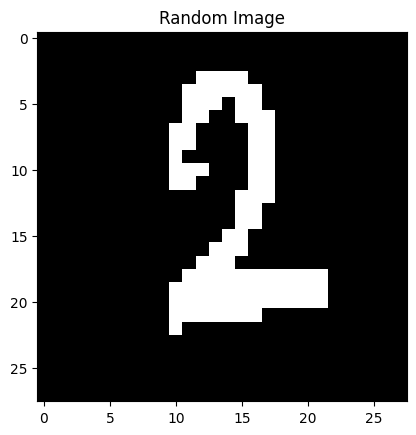

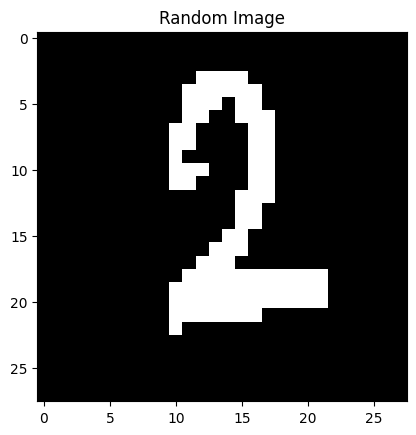

In [32]:
img = random_img()

plt.imshow(img, cmap = "gray")
plt.title("Random Image")
plt.show()

plt.imshow(img, cmap = "gray")
plt.title("Random Image")
plt.show()

In [35]:
model = Sequential()

model.add(Conv2D(32, kernel_size=3, padding="same", activation='relu', input_shape=(28, 28, 1)))
model.add(Conv2D(32, kernel_size=3, activation='relu'))
model.add(MaxPooling2D(pool_size=2, strides=2))  # 13x13

model.add(Conv2D(64, kernel_size=3, padding="same", activation='relu'))
model.add(Conv2D(64, kernel_size=3, activation='relu'))
model.add(MaxPooling2D(pool_size=2, strides=2))  # 5x5

model.add(Conv2D(128, kernel_size=3, padding="same", activation='relu'))
model.add(Conv2D(128, kernel_size=3, activation='relu'))
model.add(MaxPooling2D(pool_size=2, strides=2))  # 1x1

model.add(Conv2D(256, kernel_size=3, padding="same", activation='relu'))
# model.add(Conv2D(256, kernel_size=3, activation='relu'))  
# model.add(MaxPooling2D(pool_size=2, strides=2))  

model.add(GlobalAveragePooling2D()) 

model.add(Dropout(0.15))
#model.add(Flatten())  
model.add(Dense(500, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_69 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 26, 26, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (None, 3, 3, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 1, 1, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 500)            │       128,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 715,110 (2.73 MB)

 Trainable params: 715,110 (2.73 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def custom_preprocessing(img):
    
    # Apply thresholding
    _, img = cv2.threshold(img, 85, 255, cv2.THRESH_BINARY)

    img = np.expand_dims(img, axis=-1)
    
    return img


In [ ]:
data_gen = ImageDataGenerator(rescale= 1/ 255, validation_split= 0.25)



# preprocessing_function=custom_preprocessing,
#                               zoom_range=[0.8, 1],
#                               width_shift_range=0.15,
#                               height_shift_range=0.15


train_generator = data_gen.flow_from_directory(
    train_dir,
    target_size=(32, 32),
    color_mode='grayscale',
    batch_size=32,
    class_mode='sparse',
    subset='training'
)

validation_generator = data_gen.flow_from_directory(
    train_dir,
    target_size=(32, 32),
    color_mode='grayscale',
    batch_size=32,
    class_mode='sparse',
    subset='validation'
)


Found 45000 images belonging to 10 classes.
Found 15000 images belonging to 10 classes.


In [ ]:
training_history = model.fit(train_generator, validation_data= validation_generator, epochs=10)

In [21]:
fldrs = os.listdir(valid_dir)

z = 6001

err= []

for fldr in fldrs:
    working_fldr = os.path.join(valid_dir, fldr)
    imgs = os.listdir(working_fldr)
    to_fldr = os.path.join(train_dir, fldr)

    

    for img in imgs:
        img_path = os.path.join(working_fldr, img)

        img = img.split(".png")[0]
        img = int(img) + z 
        z+= 1

        to_img_path = os.path.join(to_fldr, f"{str(img)}.png")
        image = cv2.imread(img_path)
        

        #print(img_path, '\n', to_img_path, '\n\n')
        

        try:
            cv2.imwrite(to_img_path, image)

        except:
            err.append(img_path)

In [4]:
with open("model.json", "r") as file:
    history = json.load(file)

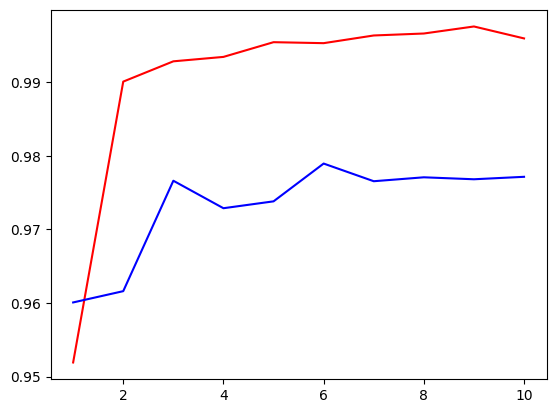

In [9]:
epochs = [i for i in range(1,11)]

plt.plot(epochs, history["accuracy"], label = "Training", color=  "red")
plt.plot(epochs, history["val_accuracy"], label = "Training", color=  "blue")


plt.show()

In [35]:
model = load_model("model_3.keras")
user = os.path.join(working_dir, "user_test")


In [36]:

# Canvas settings
GRID_SIZE = 28  # 28x28 grid similar to MNIST
PIXEL_SIZE = 20  # Size of each square

class PixelCanvas(tk.Tk):
    def __init__(self):
        super().__init__()
        self.title("Kannada Character Drawing")
        self.canvas = tk.Canvas(self, width=GRID_SIZE * PIXEL_SIZE, height=GRID_SIZE * PIXEL_SIZE, bg="black")
        self.canvas.pack()
        self.bind("<Button-1>", self.draw_pixel)
        self.bind("<B1-Motion>", self.draw_pixel)
        self.grid = [[0] * GRID_SIZE for _ in range(GRID_SIZE)]
        self.create_grid_lines()

        self.prediction_label = tk.Label(self, text="Predicted: None", font=("Arial", 14), fg="white", bg="black")
        self.prediction_label.pack(pady=5)

        
        reset_button = tk.Button(self, text="Reset", command=self.reset_grid)
        reset_button.pack(pady=5)

        save_button = tk.Button(self, text="Save", command=self.save_image)
        save_button.pack(pady=5)

        self.predict_timer = None
        self.confidence = 0

    def reset_grid(self):
        self.canvas.delete("all")       # Clear the canvas
        self.create_grid_lines() 
        self.grid = [[0] * GRID_SIZE for _ in range(GRID_SIZE)]
        self.confidence = 0
        self.predict_timer = None
        self.prediction_label.config(text="Predicted: None")

    def create_grid_lines(self):
        for i in range(0, GRID_SIZE * PIXEL_SIZE, PIXEL_SIZE):
            self.canvas.create_line(i, 0, i, GRID_SIZE * PIXEL_SIZE, fill="gray")
            self.canvas.create_line(0, i, GRID_SIZE * PIXEL_SIZE, i, fill="gray")

    def draw_pixel(self, event):
        x, y = event.x // PIXEL_SIZE, event.y // PIXEL_SIZE
        if 0 <= x < GRID_SIZE and 0 <= y < GRID_SIZE:
            self.grid[y][x] = 1
            self.canvas.create_rectangle(x * PIXEL_SIZE, y * PIXEL_SIZE,
                                         (x + 1) * PIXEL_SIZE, (y + 1) * PIXEL_SIZE,
                                         fill="white", outline="gray")
        
        if self.predict_timer:
            self.after_cancel(self.predict_timer)
        self.predict_timer = self.after(300, self.predict_character) 


    def preprocess_image(self):
        # Normalize the image for model input
        img = np.array(self.grid, dtype=np.float32)
        img = img.reshape(1, 28, 28, 1)
        return img

    def predict_character(self):
        img = self.preprocess_image()
        prediction = model.predict(img)
        num = np.argmax(prediction)
        self.confidence = np.max(prediction) * 100

        self.prediction_label.config(text=f"Predicted: {num} ({self.confidence:.2f}% confident)")


    def save_image(self):
        img = Image.new('L', (GRID_SIZE, GRID_SIZE), 0)
        pixels = img.load()
        for y in range(GRID_SIZE):
            for x in range(GRID_SIZE):
                pixels[x, y] = 255 if self.grid[y][x] == 1 else 0

        

        path = os.path.join(user, "test.png")
        img.save(path)


        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (28,28))
        img = img.reshape(1, 28, 28, 1)

        num = np.argmax(model.predict(img))
        print("Predicted: ", num)

if __name__ == "__main__":
    app = PixelCanvas()
    app.mainloop()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 794ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


In [17]:
test_imgs = os.listdir(test_dir)
submission = pd.read_csv("sample_submission.csv")

In [ ]:


for img in test_imgs:

    id = int(img.split(".png")[0])
    path = os.path.join(test_dir, img)

    t_img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    t_image = cv2.resize(t_img, (28,28))
    t_image = t_image.reshape(1, 28, 28, 1)

    num = np.argmax(model.predict(t_image))

    submission.loc[submission['id'] == id, 'label'] = num

    submission.to_csv("sample_submission.csv", index=False)

    




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━

KeyboardInterrupt: 

In [32]:
df = pd.read_csv("sample_submission.csv")


In [ ]:
df.sample(10

,id,label
540,540,6
3595,3595,9
1313,1313,0
4950,4950,6
4429,4429,7
1380,1380,2
3516,3516,2
4769,4769,5
1679,1679,7
3364,3364,6
